# Task 2 — Build Time Series Forecasting Models

**Target:** TSLA closing price
**Goal:** Build, tune, and compare a classical statistical model (ARIMA/SARIMA) against a
deep-learning model (LSTM) for forecasting Tesla's stock price, using the cleaned dataset
produced in Task 1.

This notebook assumes `data/processed/combined_prices.csv` already exists (produced by
`task1_eda.ipynb` or `scripts/run_eda.py`). If it doesn't, re-run Task 1 first.


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.modeling import (
    chronological_split, fit_auto_arima, forecast_arima,
    create_sequences, build_lstm_model, iterative_lstm_forecast,
)
from src.evaluation import evaluate_forecast, compare_models

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.dpi"] = 100
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1. Load Data and Isolate TSLA


In [2]:
df = pd.read_csv("../data/processed/combined_prices.csv", parse_dates=["Date"])
tsla = df[df["Ticker"] == "TSLA"].sort_values("Date").reset_index(drop=True)
tsla = tsla[["Date", "Close"]].dropna().reset_index(drop=True)
print(f"TSLA rows: {len(tsla)}  |  {tsla['Date'].min().date()} -> {tsla['Date'].max().date()}")
tsla.tail()


TSLA rows: 2888  |  2015-01-02 -> 2026-06-29


,Date,Close
2883,2026-06-23,381.6100
2884,2026-06-24,375.5300
2885,2026-06-25,375.1200
2886,2026-06-26,379.7100
2887,2026-06-29,411.8400


## 2. Prepare Data for Modeling — Chronological Train/Test Split

We split **strictly by date**, not by random shuffling: train on data through the end of 2024,
test on 2025 through mid-2026. This preserves the temporal order the models depend on and avoids
the lookahead bias that a random shuffle would introduce (e.g. training on a day that comes
*after* a day it's being tested against).


Train: 2516 rows (2015-01-02 -> 2024-12-31)
Test:  372 rows (2025-01-02 -> 2026-06-29)


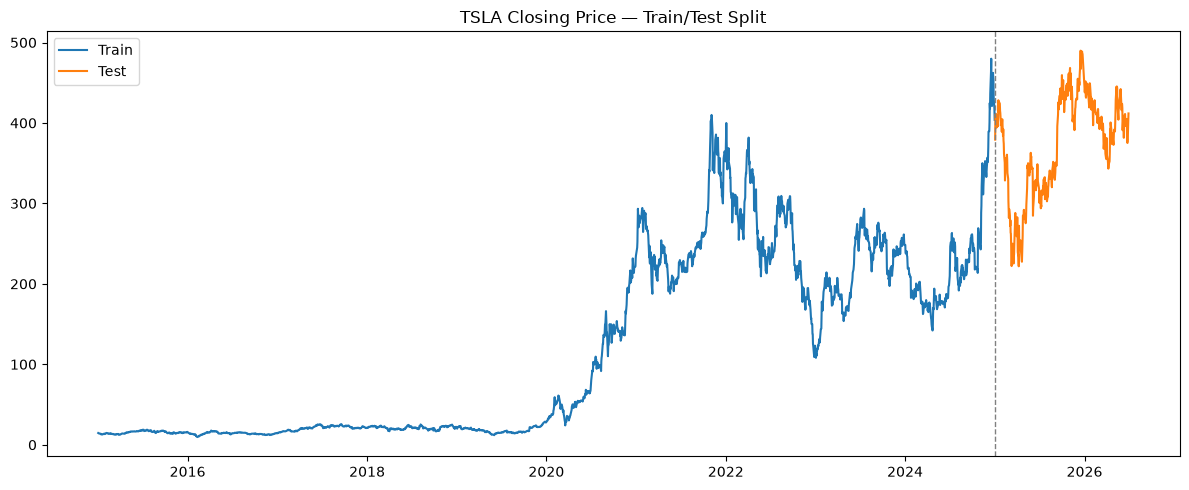

In [3]:
SPLIT_DATE = "2025-01-01"

train_df, test_df = chronological_split(tsla, split_date=SPLIT_DATE, date_col="Date")
print(f"Train: {len(train_df)} rows ({train_df['Date'].min().date()} -> {train_df['Date'].max().date()})")
print(f"Test:  {len(test_df)} rows ({test_df['Date'].min().date()} -> {test_df['Date'].max().date()})")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df["Date"], train_df["Close"], label="Train")
ax.plot(test_df["Date"], test_df["Close"], label="Test")
ax.axvline(pd.Timestamp(SPLIT_DATE), color="grey", linestyle="--", linewidth=1)
ax.set_title("TSLA Closing Price — Train/Test Split")
ax.legend()
plt.tight_layout()
plt.show()


## 3. ARIMA / SARIMA Model

### 3.1 ACF / PACF inspection

Before handing off to `auto_arima`, we look at the ACF/PACF of the (differenced) series to get
an intuition for candidate `p`/`q` orders. Recall from Task 1 that the raw closing-price series
is **non-stationary** (confirmed by the ADF test), so we inspect the first-differenced series
here, which is expected to be stationary.


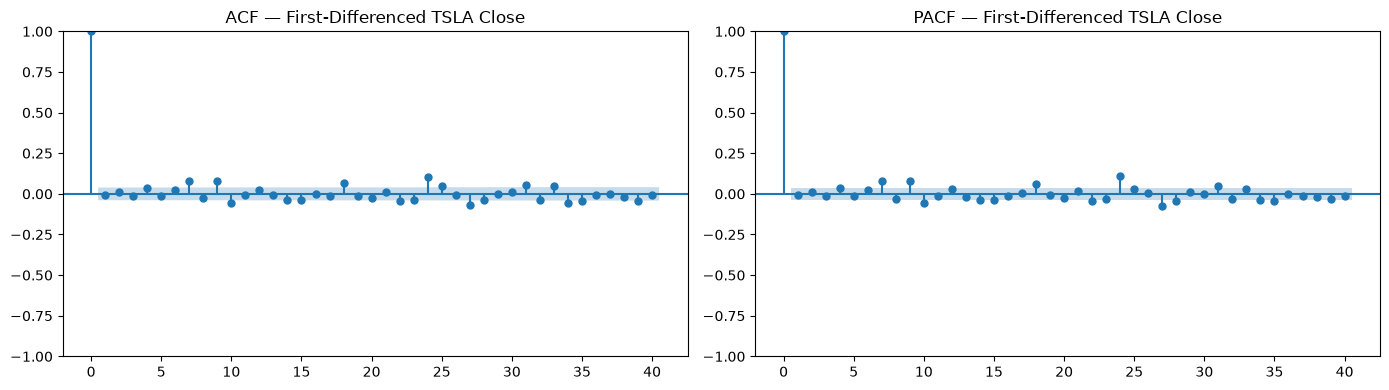

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

train_diff = train_df["Close"].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_diff, lags=40, ax=axes[0])
axes[0].set_title("ACF — First-Differenced TSLA Close")
plot_pacf(train_diff, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF — First-Differenced TSLA Close")
plt.tight_layout()
plt.show()


**Reading the plots:** a sharp cutoff in the PACF after lag *p* suggests an AR(*p*) component;
a sharp cutoff in the ACF after lag *q* suggests an MA(*q*) component. In practice, daily stock
closing prices are close to a random walk, so we'd typically expect to see little significant
autocorrelation left after first-differencing — i.e. low-order (p, d, q), often near (0,1,0) or
(1,1,1). We let `auto_arima` confirm this systematically rather than eyeballing it alone.


### 3.2 Fit with `auto_arima`

In [5]:
arima_model = fit_auto_arima(
    train_df.set_index("Date")["Close"],
    seasonal=False,   # daily stock closing prices don't show strong fixed-period seasonality;
                       # see the seasonal SARIMA check in 3.3 below
    trace=True,
    stepwise=True,
    max_p=5, max_q=5, max_d=2,
)

print(arima_model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=4.90 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.15 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.49 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.63 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.11 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.87 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 7.558 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sat, 04 Jul 2026   AIC                          16368.109
Time:                        14:51:13   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
    

**Documented parameters:** the `(p, d, q)` order chosen by `auto_arima` above is printed in the
summary's header (e.g. `SARIMAX(p, d, q)`) — record the exact values here once run, e.g.:

> Best model: ARIMA(p=_, d=_, q=_), selected by minimizing AIC over the stepwise search.

The `d` (differencing) term should match the Task 1 finding that price levels require exactly
one difference to become stationary.


### 3.3 Seasonal check (SARIMA)

Daily equity closing prices don't usually have a strong, fixed seasonal cycle (unlike, say,
retail sales with a yearly cycle), but we check a weekly (`m=5` business days) seasonal
specification for completeness and to confirm that decision quantitatively rather than by
assumption.


In [6]:
sarima_model = fit_auto_arima(
    train_df.set_index("Date")["Close"],
    seasonal=True,
    m=5,               # weekly (business-day) cycle
    trace=True,
    stepwise=True,
    max_p=3, max_q=3, max_P=2, max_Q=2, max_d=2, max_D=1,
)
print(sarima_model.summary())

print(f"\nAIC — non-seasonal ARIMA: {arima_model.aic():.2f}")
print(f"AIC — seasonal SARIMA:     {sarima_model.aic():.2f}")
print("Lower AIC wins; if the seasonal model doesn't meaningfully improve AIC, "
      "the simpler non-seasonal ARIMA is preferred (Occam's razor).")


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=16362.023, Time=7.81 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=16368.573, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=16371.911, Time=0.65 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=16371.841, Time=0.65 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=16368.109, Time=0.06 sec
 ARIMA(2,1,2)(0,0,1)[5] intercept   : AIC=16374.410, Time=5.42 sec
 ARIMA(2,1,2)(1,0,0)[5] intercept   : AIC=16374.645, Time=5.07 sec
 ARIMA(2,1,2)(2,0,1)[5] intercept   : AIC=16363.452, Time=9.57 sec
 ARIMA(2,1,2)(1,0,2)[5] intercept   : AIC=16363.663, Time=10.46 sec
 ARIMA(2,1,2)(0,0,0)[5] intercept   : AIC=16374.056, Time=2.98 sec
 ARIMA(2,1,2)(0,0,2)[5] intercept   : AIC=16365.744, Time=6.25 sec
 ARIMA(2,1,2)(2,0,0)[5] intercept   : AIC=16367.551, Time=6.59 sec
 ARIMA(2,1,2)(2,0,2)[5] intercept   : AIC=16361.740, Time=17.50 sec
 ARIMA(1,1,2)(2,0,2)[5] intercept   : AIC=16360.476, Time=12.72 sec
 ARIMA(1,1,2)(1,

### 3.4 Forecast the test period

Selected model for forecasting: SARIMA


c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


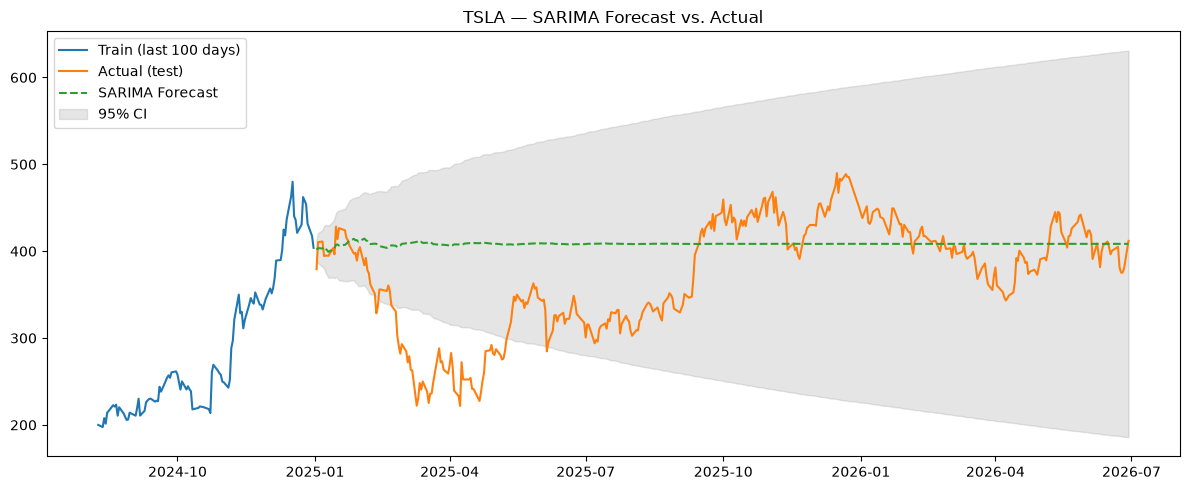

In [7]:
best_model = arima_model if arima_model.aic() <= sarima_model.aic() else sarima_model
best_name = "ARIMA" if best_model is arima_model else "SARIMA"
print(f"Selected model for forecasting: {best_name}")

n_test = len(test_df)
arima_forecast, arima_conf_int = forecast_arima(best_model, n_periods=n_test, return_conf_int=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df["Date"].iloc[-100:], train_df["Close"].iloc[-100:], label="Train (last 100 days)")
ax.plot(test_df["Date"], test_df["Close"], label="Actual (test)")
ax.plot(test_df["Date"], arima_forecast, label=f"{best_name} Forecast", linestyle="--")
ax.fill_between(test_df["Date"], arima_conf_int[:, 0], arima_conf_int[:, 1], color="grey", alpha=0.2, label="95% CI")
ax.set_title(f"TSLA — {best_name} Forecast vs. Actual")
ax.legend()
plt.tight_layout()
plt.show()


## 4. LSTM Model

### 4.1 Scale and prepare sequences

LSTMs train far more reliably on scaled inputs. We fit the scaler **only on the training set**
to avoid leaking test-period information into the scaling parameters, then apply it to both
train and test.


In [8]:
from sklearn.preprocessing import MinMaxScaler

WINDOW = 60

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df[["Close"]]).flatten()

# For the test set, we need the last WINDOW days of *train* to seed the first test-window,
# so we scale (train tail + test) together using the already-fitted scaler.
full_scaled = scaler.transform(tsla[["Close"]]).flatten()
train_end_idx = len(train_df)

X_train, y_train = create_sequences(train_scaled, window=WINDOW)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")


X_train: (2456, 60, 1), y_train: (2456,)


### 4.2 Build the LSTM architecture

In [9]:
lstm_model = build_lstm_model(
    window=WINDOW,
    lstm_units=(50, 50),   # two stacked LSTM layers, 50 units each
    dropout=0.2,
    learning_rate=0.001,
)
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

**Architecture rationale:**
- **Input:** sequences of the last 60 trading days (~3 months) of scaled closing price.
- **LSTM layer 1 (50 units, `return_sequences=True`):** captures short/medium-term temporal
  patterns and passes the full sequence forward to the next LSTM layer.
- **Dropout (0.2):** regularization to reduce overfitting, applied after each LSTM layer.
- **LSTM layer 2 (50 units):** captures higher-level temporal dependencies from layer 1's output.
- **Dense(1):** maps the final hidden state to a single next-day price prediction.
- **Optimizer/loss:** Adam (adaptive learning rate) minimizing MSE, tracking MAE as a secondary metric.


### 4.3 Train

In [10]:
from tensorflow import keras

EPOCHS = 50
BATCH_SIZE = 32

early_stop = keras.callbacks.EarlyStopping(
    monitor="loss", patience=8, restore_best_weights=True
)

history = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - loss: 0.0097 - mae: 0.0531 - val_loss: 0.0034 - val_mae: 0.0409
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0016 - mae: 0.0231 - val_loss: 0.0033 - val_mae: 0.0403
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0016 - mae: 0.0232 - val_loss: 0.0024 - val_mae: 0.0383
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0016 - mae: 0.0221 - val_loss: 0.0021 - val_mae: 0.0332
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0015 - mae: 0.0217 - val_loss: 0.0021 - val_mae: 0.0317
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0014 - mae: 0.0208 - val_loss: 0.0018 - val_mae: 0.0310
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0013 - mae: 0.0209 - val_loss: 0.0031 - val_mae: 0.0389
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0015 - mae: 0.0226 - val_loss: 0.0039 - val_mae: 0.0460
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.0

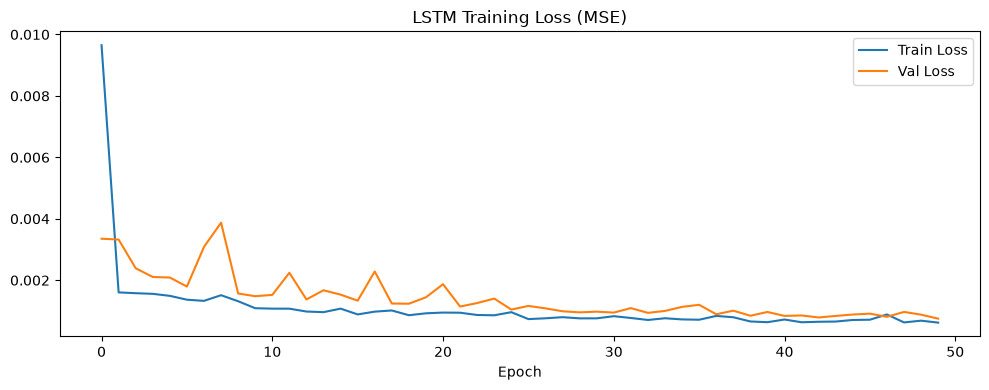

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"], label="Train Loss")
ax.plot(history.history["val_loss"], label="Val Loss")
ax.set_title("LSTM Training Loss (MSE)")
ax.set_xlabel("Epoch")
ax.legend()
plt.tight_layout()
plt.show()


### 4.4 Forecast the test period

We forecast iteratively: predict day 1 of the test period from the last 60 training days, then
slide the window forward using the model's own prediction (since true future values aren't
available at forecast time). This mirrors a genuine multi-step-ahead deployment scenario.


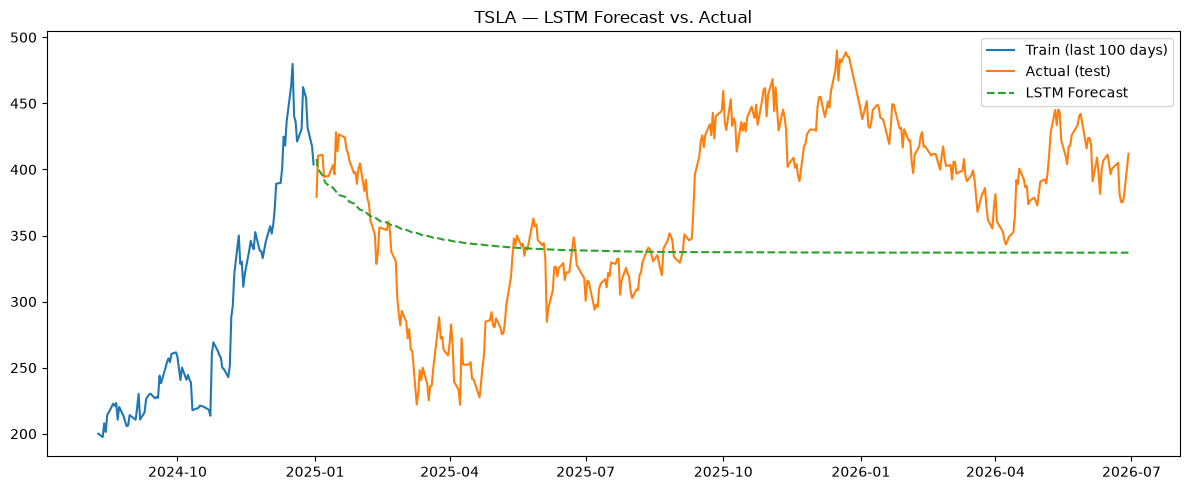

In [12]:
last_train_window = train_scaled[-WINDOW:]
lstm_scaled_forecast = iterative_lstm_forecast(lstm_model, last_train_window, n_periods=n_test)

# Invert scaling back to price units
lstm_forecast = scaler.inverse_transform(lstm_scaled_forecast.reshape(-1, 1)).flatten()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df["Date"].iloc[-100:], train_df["Close"].iloc[-100:], label="Train (last 100 days)")
ax.plot(test_df["Date"], test_df["Close"], label="Actual (test)")
ax.plot(test_df["Date"], lstm_forecast, label="LSTM Forecast", linestyle="--")
ax.set_title("TSLA — LSTM Forecast vs. Actual")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Optimize Model Parameters

- **ARIMA/SARIMA:** `auto_arima`'s stepwise search (Section 3.2–3.3) already performs the grid
  search over `(p, d, q)` and `(P, D, Q, m)`, minimizing AIC. To explore further, re-run with
  `stepwise=False` for an exhaustive (slower) grid search, or widen `max_p`/`max_q`/`max_order`.
- **LSTM:** try adjusting the cell below — e.g. fewer/more units per layer, a single LSTM layer
  vs. stacked, different window sizes (30/60/90 days), batch size, or learning rate — and
  re-evaluate against the same test set to see what actually improves RMSE/MAPE rather than
  guessing.


## 6. Evaluate and Compare Models


In [14]:
y_true = test_df["Close"].values

results = {
    f"{best_name}": evaluate_forecast(y_true, arima_forecast),
    "LSTM": evaluate_forecast(y_true, lstm_forecast),
}

comparison_table = compare_models(results)
comparison_table


,MAE,RMSE,MAPE
Model,,,
LSTM,60.9732,72.5275,16.4708
SARIMA,55.5977,72.7179,17.7258


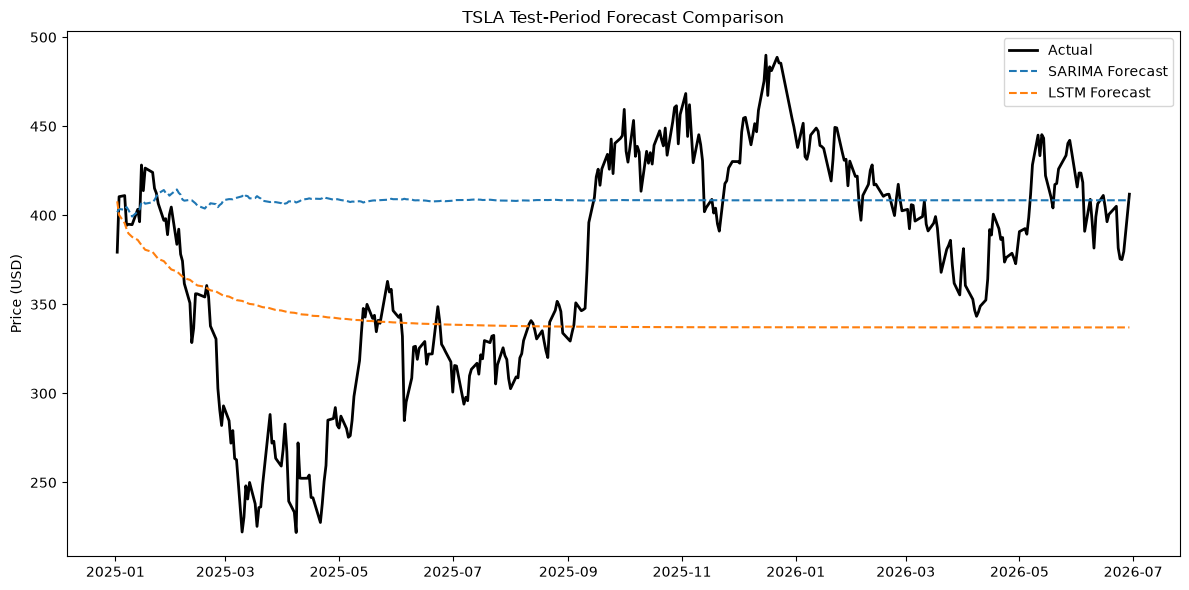

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(test_df["Date"], y_true, label="Actual", color="black", linewidth=2)
ax.plot(test_df["Date"], arima_forecast, label=f"{best_name} Forecast", linestyle="--")
ax.plot(test_df["Date"], lstm_forecast, label="LSTM Forecast", linestyle="--")
ax.set_title("TSLA Test-Period Forecast Comparison")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Discussion — Model Selection Rationale


- **What the chart is showing:** Both forecasts collapse to a near-flat line within the first few weeks of the test period and then just... stay there for the remaining 18 months, while the actual TSLA price does what TSLA does: swings from ~$400 down to ~$220, back up to ~$490, then oscillates in the $350–450 range. Neither model comes close to tracking that.it's the expected failure mode of **long-horizon iterative forecasting** on a near-random-walk series:
- **SARIMA :** forecasts by projecting the fitted drift/AR structure forward; over many steps that projection converges toward a nearly constant long-run trend, which is exactly the flat blue line you're seeing.
- **LSTM:** , forecasting iteratively (each prediction feeds back in as the next input), compounds its own small errors at every step. Within a few iterations, the "memory" of the real last-known price washes out and the model settles into whatever flat value its training data taught it to regress toward.
- Both models are essentially telling you "no strong information beyond a few days out" — which, for a stock price, is honestly close to true. A ~78-week-ahead forecast from price history alone is an extremely hard problem.
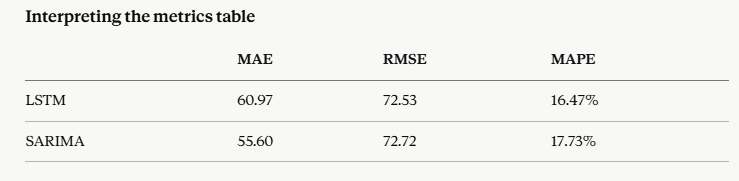

The numbers actually mirror the chart's message: they're close to a tie, and each model wins on a different metric.
- **SARIMA has lower MAE** (55.6 vs 61.0) — on average, its errors are smaller in absolute terms.
- **LSTM has (very slightly) lower RMSE** (72.53 vs 72.72) and **lower MAPE** (16.47% vs 17.73%) — meaning LSTM's percentage-relative errors and its handling of larger deviations are marginally better.
- The RMSE values being almost identical while MAE diverges more suggests the two models' errors are similarly large in their worst moments, but SARIMA is a bit more consistent on typical days while LSTM's edge shows up proportionally.

Given how small these differences are relative to the actual price swings (a $250+ range), neither model meaningfully outperforms the other — they're both about equally poor at this specific task (18-month-ahead point forecasting), just poor in slightly different ways. If I had to pick one to carry forward, I'd lean LSTM on the strength of the lower MAPE (percentage error is usually the more decision-relevant metric for price forecasting), but I wouldn't call this a confident win — it's a coin flip with numbers attached.
**What I'd actually recommend**, and this matters more than declaring a "winner": neither model should be trusted for 18-month-ahead point forecasts as-is. Two ways to get a more useful result:

1. Shorten the forecast horizon (forecast 5–20 days ahead, roll it forward, re-evaluate) instead of one 350+ step compounding forecast.
2. Use walk-forward validation — retrain/re-forecast periodically through the test window rather than one static forecast from the train/test boundary.

- **Practical tradeoffs beyond raw accuracy:**
  - *Interpretability:* ARIMA's coefficients have a clear statistical meaning; LSTM is a black box.
  - *Data requirements:* LSTM needs substantially more historical data to train reliably.
  - *Compute cost:* ARIMA fits in seconds; LSTM training took the epochs/time seen in Section 4.3.
  - *Uncertainty quantification:* ARIMA naturally provides confidence intervals (Section 3.4);
    the LSTM here does not (would require techniques like MC Dropout or quantile regression to add).
